---
---
---

# EnergyPlus AI: Inference

---
---
---

<br>

> **_Abstract:_** ...

> **_Table of Contents:_**
>
> 1. DataFrame
> 2. Training
>     - Train-Test Split
>     - Final Model
> 3. Testing
> 4. Artifacts
> 5. Conclusion

<br>

> | **Language: python@3.11** |
> | - |

<br>

> | **_Source:_** [**_EnergyPlus AI: Inference_**](https://www.kaggle.com/code/robertovicario/energuplus-ai-inference) |
> | - |

<br>

> | **_Libraries:_** [**_github.com/robertovicario/EnergyPlus-AI/notebook/lib_**](https://github.com/robertovicario/EnergyPlus-AI/tree/main/notebook/lib) |
> | - |

<br>

---
---
---

## Dependencies

### Packages

In [1]:
from joblib import load
from loguru import logger
from sklearn.model_selection import train_test_split
import numpy as np
import os
import pandas as pd
import warnings

# -------------------------

warnings.filterwarnings('ignore')

### Paths

In [2]:
DATA_PATH = os.path.join('..', 'data')
MODELS_PATH = os.path.join('..', 'models')

### Configurations

In [3]:
config = {
    'model': {
        'name': 'Energy_Model',
        'task': 'Regression',
        'dataset': 'udse.parquet',
        'target': 'EUI'
    },
    'training': {
        'df_rows': 0,
		'df_columns': 0,
        'frac': 1.0,
        'test_size': 0.2,
        'n_jobs': -1,
        'random_state': 42,
        'shuffle': True
    }
}

## DataFrame

> **_Source:_** [**_EnergyPlus AI: Training DataFrame_**](https://www.kaggle.com/code/robertovicario/energyplus-ai-training-dataframe)

In [4]:
df = pd.read_parquet(
    os.path.join(DATA_PATH, 'udse.parquet'),
    engine='fastparquet'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255036 entries, 0 to 260747
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   Building-Type    255036 non-null  category
 1   Climate-Zone     255036 non-null  category
 2   Total-Area       255036 non-null  float64 
 3   Floor-Area       255036 non-null  float64 
 4   Num-Floors       255036 non-null  float64 
 5   Building-Depth   255036 non-null  float64 
 6   Building-Length  255036 non-null  float64 
 7   Building-Height  255036 non-null  float64 
 8   Floor-Height     255036 non-null  float64 
 9   WWR              255036 non-null  float64 
 10  Wall-R-Value     255036 non-null  category
 11  Roof-R-Value     255036 non-null  category
 12  Window-U-Value   255036 non-null  category
 13  SHGC             255036 non-null  category
 14  EUI              255036 non-null  float64 
 15  HVAC-Type        255036 non-null  category
 16  HVAC-AC          255036 n

## Inference

### Train-Test Split

In [5]:
# Feature Selection
X = df.drop(columns=['EUI'])
y = df['EUI']

# Fractional Sampling
frac = config['training']['frac']
subset = int(len(X) * frac)
X = X.iloc[:subset]
y = y.iloc[:subset]
config['training']['df_rows'] = df.shape[0]
config['training']['df_columns'] = df.shape[1]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config['training']['test_size'],
    random_state=config['training']['random_state'],
    shuffle=config['training']['shuffle']
)

# -------------------------

logger.debug(f"DF{'':<4}(Shape): {X.shape}")
logger.debug(f"TRAIN{'':<1}(Shape): {X_train.shape}")
logger.debug(f"TEST{'':<2}(Shape): {X_test.shape}")

2026-04-27 16:29:25.684 | DEBUG    | __main__:<module>:23 - DF    (Shape): (255036, 22)
2026-04-27 16:29:25.685 | DEBUG    | __main__:<module>:24 - TRAIN (Shape): (204028, 22)
2026-04-27 16:29:25.685 | DEBUG    | __main__:<module>:25 - TEST  (Shape): (51008, 22)


In [6]:
model = load(os.path.join(MODELS_PATH, 'registry', 'model.joblib'))
display(model)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",HistGradientB...ndom_state=42)
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.047006594771349115
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",301
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",25
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None


In [7]:
y.describe()

count    255036.000000
mean        132.211597
std         162.203232
min          18.086152
25%          45.613598
50%          72.962024
75%         100.841246
max        1070.272026
Name: EUI, dtype: float64

## Benchmarking

> Se voglio:
> - errore <10% → il modello è affidabile solo nel ~70% dei casi
> - errore <20% → affidabile nel ~95% dei casi
> - errore <30% → affidabile nel ~98% dei casi
>
> 🔹 Caso 2 — alert sistema: flag se predizione nel range problematico


Sample predictions:


,actual,predicted,abs_error,rel_error
index,,,,
248580,102.778400,88.996706,13.781693,0.134091
93587,82.985383,80.758153,2.227230,0.026839
37108,79.893206,72.925985,6.967221,0.087207
52124,31.089195,35.629421,4.540226,0.146039
60679,85.496581,88.882571,3.385990,0.039604
197200,45.342856,39.386791,5.956065,0.131356
163800,37.818106,37.202206,0.615900,0.016286
32945,65.489800,68.583480,3.093680,0.047239
184630,25.684565,29.403383,3.718817,0.144788



=== BENCHMARK ===
Total samples: 51008

--- Fixed threshold ---
Condition: rel_error > 0.3 AND abs_error > 30
Bad predictions: 794
Failure rate: 1.56%

--- Dynamic threshold (90th percentile) ---
Threshold rel_error: 0.152
Bad predictions: 5101
Failure rate: 10.00%

Error distribution:


count    51008.000000
mean         0.073415
std          0.066482
min          0.000001
25%          0.024680
50%          0.055596
75%          0.103591
max          0.442406
Name: rel_error, dtype: float64


Worst predictions:


,actual,predicted,abs_error,rel_error,is_bad_fixed,is_bad_dynamic
index,,,,,,
50229,39.260430,56.629496,17.369067,0.442406,False,True
49653,39.764641,56.190767,16.426126,0.413084,False,True
52485,39.075305,55.132872,16.057568,0.410939,False,True
47421,31.091673,43.768443,12.676770,0.407722,False,True
53808,87.924383,52.349837,35.574546,0.404604,True,True
49557,36.810419,51.683770,14.873351,0.404053,False,True
52389,34.320707,48.174619,13.853912,0.403660,False,True
50133,35.186503,49.273803,14.087300,0.400361,False,True
50208,93.863890,56.629496,37.234394,0.396685,True,True


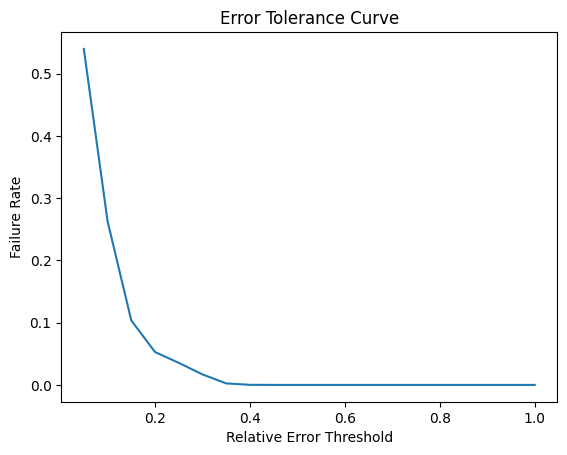

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
}, index=X_test.index)

# =========================
# ERROR METRICS
# =========================
results["abs_error"] = np.abs(results["actual"] - results["predicted"])
results["rel_error"] = results["abs_error"] / results["actual"]

# =========================
# PRINT SAMPLE
# =========================
print("\nSample predictions:")
display(results.head(10))

# =========================
# THRESHOLD 1 (FIXED)
# =========================
TH_REL = 0.3
TH_ABS = 30

results["is_bad_fixed"] = (
    (results["rel_error"] > TH_REL) &
    (results["abs_error"] > TH_ABS)
)

# =========================
# THRESHOLD 2 (DATA-DRIVEN)
# =========================
th_rel_dynamic = results["rel_error"].quantile(0.90)

results["is_bad_dynamic"] = results["rel_error"] > th_rel_dynamic

# =========================
# BENCHMARK
# =========================
total = len(results)

bad_fixed = results["is_bad_fixed"].sum()
bad_dynamic = results["is_bad_dynamic"].sum()

print("\n=== BENCHMARK ===")
print(f"Total samples: {total}")

print("\n--- Fixed threshold ---")
print(f"Condition: rel_error > {TH_REL} AND abs_error > {TH_ABS}")
print(f"Bad predictions: {bad_fixed}")
print(f"Failure rate: {bad_fixed/total:.2%}")

print("\n--- Dynamic threshold (90th percentile) ---")
print(f"Threshold rel_error: {th_rel_dynamic:.3f}")
print(f"Bad predictions: {bad_dynamic}")
print(f"Failure rate: {bad_dynamic/total:.2%}")

# =========================
# ERROR DISTRIBUTION
# =========================
print("\nError distribution:")
display(results["rel_error"].describe())

# =========================
# WORST CASES
# =========================
print("\nWorst predictions:")
display(results.sort_values("rel_error", ascending=False).head(10))

# =========================
# ERROR TOLERANCE CURVE
# =========================
thresholds = np.linspace(0.05, 1.0, 20)
failure_rates = []

for t in thresholds:
    fail_rate = (results["rel_error"] > t).mean()
    failure_rates.append(fail_rate)

plt.figure()

plt.plot(thresholds, failure_rates)
plt.xlabel("Relative Error Threshold")
plt.ylabel("Failure Rate")
plt.title("Error Tolerance Curve")

plt.show()

Bad cases: 794 / 51008

=== NUMERIC FEATURES ANALYSIS ===


,feature,good_mean,bad_mean,difference,abs_diff
0,Total-Area,199081.944557,147662.899244,-51419.045313,51419.045313
1,Floor-Area,25814.890847,27239.978589,1425.087742,1425.087742
4,Building-Length,211.565858,169.741814,-41.824045,41.824045
5,Building-Height,129.061258,98.774559,-30.286699,30.286699
3,Building-Depth,96.407715,120.578086,24.170371,24.170371
7,WWR,59.499639,52.671214,-6.828424,6.828424
2,Num-Floors,8.852810,6.484887,-2.367923,2.367923
6,Floor-Height,14.576433,15.190176,0.613743,0.613743



=== CATEGORICAL FEATURES ANALYSIS ===

Feature: Building-Type


Building-Type
Laboratory           0.099597
HighriseApartment    0.001537
Hospital             0.000109
College              0.000000
LargeOffice          0.000000
MediumOffice         0.000000
MidriseApartment     0.000000
Outpatient           0.000000
Name: is_bad, dtype: float64


Feature: Climate-Zone


Climate-Zone
1A    0.019913
4A    0.019741
4C    0.019740
3A    0.018433
3C    0.017727
3B    0.017535
2B    0.016645
2A    0.016064
5A    0.015634
6A    0.012520
Name: is_bad, dtype: float64


Feature: Wall-R-Value


Wall-R-Value
12.33    0.019090
8.33     0.018998
13.33    0.018587
30.00    0.016112
16.33    0.016058
20.33    0.012424
25.00    0.012377
18.33    0.008981
Name: is_bad, dtype: float64


Feature: Roof-R-Value


Roof-R-Value
21.34    0.018998
26.34    0.018749
60.00    0.017111
31.34    0.014068
45.00    0.012921
36.34    0.011142
50.00    0.007371
Name: is_bad, dtype: float64


Feature: Window-U-Value


Window-U-Value
0.66    0.019061
0.61    0.017246
0.20    0.017111
0.37    0.014321
0.52    0.013158
0.46    0.011142
Name: is_bad, dtype: float64

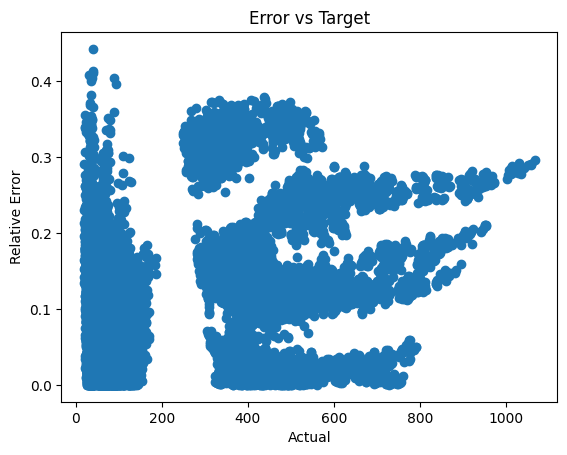


Error distribution:
error_bucket
<10%      0.736963
10-20%    0.210202
20-30%    0.035994
>30%      0.016840
Name: proportion, dtype: float64

Worst cases:


,Building-Type,Climate-Zone,Total-Area,Floor-Area,Num-Floors,Building-Depth,Building-Length,Building-Height,Floor-Height,WWR,...,HVAC-Electric,HVAC-Gas,HVAC-HP,HVAC-Reheat,actual,predicted,abs_error,rel_error,is_bad,error_bucket
index,,,,,,,,,,,,,,,,,,,,,
50229,HighriseApartment,4B,299990.0,15000.0,20.0,45.0,401.0,280.0,14.0,89.910314,...,False,True,False,True,39.260430,56.629496,17.369067,0.442406,False,>30%
49653,HighriseApartment,4A,299726.0,14986.0,20.0,62.0,280.0,280.0,14.0,81.871345,...,False,True,False,True,39.764641,56.190767,16.426126,0.413084,False,>30%
52485,HighriseApartment,5B,299990.0,15000.0,20.0,45.0,401.0,280.0,14.0,89.910314,...,False,True,False,True,39.075305,55.132872,16.057568,0.410939,False,>30%
47421,HighriseApartment,3A,299990.0,15000.0,20.0,45.0,401.0,240.0,12.0,89.910314,...,False,True,False,True,31.091673,43.768443,12.676770,0.407722,False,>30%
53808,HighriseApartment,6B,299990.0,15000.0,20.0,45.0,401.0,280.0,14.0,89.910314,...,False,True,False,True,87.924383,52.349837,35.574546,0.404604,True,>30%
49557,HighriseApartment,4A,299726.0,14986.0,20.0,62.0,280.0,240.0,12.0,81.871345,...,False,True,False,True,36.810419,51.683770,14.873351,0.404053,False,>30%
52389,HighriseApartment,5B,299990.0,15000.0,20.0,45.0,401.0,240.0,12.0,89.910314,...,False,True,False,True,34.320707,48.174619,13.853912,0.403660,False,>30%
50133,HighriseApartment,4B,299990.0,15000.0,20.0,45.0,401.0,200.0,10.0,89.910314,...,False,True,False,True,35.186503,49.273803,14.087300,0.400361,False,>30%
50208,HighriseApartment,4B,299990.0,15000.0,20.0,45.0,401.0,280.0,14.0,89.910314,...,False,True,False,True,93.863890,56.629496,37.234394,0.396685,True,>30%


In [ ]:
import pandas as pd
import numpy as np

# =========================
# BASE DATASET
# =========================
df = X_test.copy()
df["actual"] = y_test
df["predicted"] = results["predicted"]

df["abs_error"] = np.abs(df["actual"] - df["predicted"])
df["rel_error"] = df["abs_error"] / df["actual"]

# =========================
# DEFINIZIONE ERRORI GRAVI
# =========================
TH_REL = 0.3
TH_ABS = 30

df["is_bad"] = (
    (df["rel_error"] > TH_REL) &
    (df["abs_error"] > TH_ABS)
)

print(f"Bad cases: {df['is_bad'].sum()} / {len(df)}")

# =========================
# 1. ANALISI NUMERICHE
# =========================
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ["actual", "predicted", "abs_error", "rel_error"]]

print("\n=== NUMERIC FEATURES ANALYSIS ===")

num_analysis = []

for col in num_cols:
    good_mean = df.loc[~df["is_bad"], col].mean()
    bad_mean = df.loc[df["is_bad"], col].mean()
    
    diff = bad_mean - good_mean
    
    num_analysis.append({
        "feature": col,
        "good_mean": good_mean,
        "bad_mean": bad_mean,
        "difference": diff
    })

num_analysis_df = pd.DataFrame(num_analysis)
num_analysis_df["abs_diff"] = np.abs(num_analysis_df["difference"])
num_analysis_df = num_analysis_df.sort_values("abs_diff", ascending=False)

display(num_analysis_df.head(10))

# =========================
# 2. ANALISI CATEGORICHE
# =========================
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("\n=== CATEGORICAL FEATURES ANALYSIS ===")

for col in cat_cols[:5]:  # limita output
    print(f"\nFeature: {col}")
    
    stats = df.groupby(col)["is_bad"].mean().sort_values(ascending=False)
    
    display(stats.head(10))

# =========================
# 3. ERROR vs TARGET
# =========================
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["actual"], df["rel_error"])
plt.xlabel("Actual")
plt.ylabel("Relative Error")
plt.title("Error vs Target")
plt.show()

# =========================
# 4. ERROR BUCKETS
# =========================
df["error_bucket"] = pd.cut(
    df["rel_error"],
    bins=[0, 0.1, 0.2, 0.3, 1.0],
    labels=["<10%", "10-20%", "20-30%", ">30%"]
)

print("\nError distribution:")
print(df["error_bucket"].value_counts(normalize=True))

# =========================
# 5. TOP ERROR CASES
# =========================
print("\nWorst cases:")
display(df.sort_values("rel_error", ascending=False).head(10))

Selected index: 128422
Prediction: 364.2933
Actual:     318.5629


  0%|          | 0/1 [00:00<?, ?it/s]

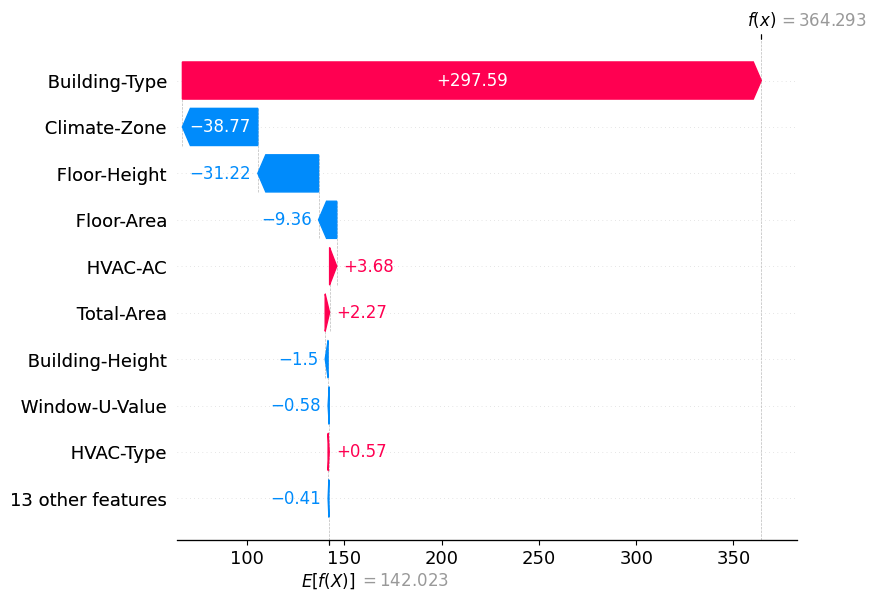

In [ ]:
# =========================
# SETUP
# =========================
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

shap.initjs()

# =========================
# FIX CATEGORY (MODEL SPACE)
# =========================
def ensure_category(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype("category")
    return df

X_train_cat = ensure_category(X_train)
X_test_cat = ensure_category(X_test)

# =========================
# ENCODER (SHAP SPACE)
# =========================
cat_cols = X_train_cat.select_dtypes(include="category").columns.tolist()

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder.fit(X_train_cat[cat_cols])

def to_shap(df):
    df = df.copy()
    df[cat_cols] = encoder.transform(df[cat_cols])
    return df

def to_model(df_enc):
    df = df_enc.copy()
    for col in cat_cols:
        categories = X_train_cat[col].cat.categories
        codes = df[col].astype(int).clip(0, len(categories)-1)
        df[col] = pd.Categorical.from_codes(codes, categories=categories)
    return df

X_train_enc = to_shap(X_train_cat)

# =========================
# LOAD MODEL
# =========================

def model_fn(X):
    X_df = pd.DataFrame(X, columns=X_train.columns)
    X_model = to_model(X_df)
    return model.predict(X_model)

# =========================
# RANDOM SAMPLE
# =========================
random_idx = np.random.choice(X_test_cat.index)
x_sample_cat = X_test_cat.loc[[random_idx]]
x_sample_enc = to_shap(x_sample_cat)

y_true = y_test.loc[random_idx]

print(f"Selected index: {random_idx}")

# =========================
# PREDICTION
# =========================
y_pred = model.predict(x_sample_cat)[0]

print(f"Prediction: {y_pred:.4f}")
print(f"Actual:     {y_true:.4f}")

# =========================
# SHAP (KernelExplainer)
# =========================
background = shap.sample(X_train_enc, 50)
explainer = shap.KernelExplainer(model_fn, background)

shap_values = explainer.shap_values(x_sample_enc)

# =========================
# WATERFALL
# =========================
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=X_train.columns,
    features=x_sample_cat.iloc[0]
)

### Final Model

In [ ]:
# model = TransformedTargetRegressor(
#     regressor=HistGradientBoostingRegressor(
#         **model_params,
#         categorical_features='from_dtype',
#         random_state=config['training']['random_state']
#     ),
#     func=np.log1p,
#     inverse_func=np.expm1
# )
# model.fit(X_train, y_train)
# display(model)

## Conclusion

> ...